# Tirando sinais digitais - $x[n]$ ... pra fora do computador - $x(t)$!

Neste Notebook iremos trabalhar em como:
1. Criar um sinal `osc`, com frequência e duração controladas.
2. Sintetizar um sinal ***periódico e aleatório***, com frequência e duração controladas.
3. Plotar sinais em amostras, $x[n]$, tempo, $x(t)$, e frequência, $\mathcal{X}(\omega)$.

Alunas: Giovana Faleiro Serafim (Matrícula: 202504001) e Yasmin Mageste Nogueira Santos (Matrícula: 202504029) 

In [3]:
pip install music21

     ---------------------------------------- 20.1/20.1 MB 4.8 MB/s eta 0:00:00
     ---------------------------------------- 1.2/1.2 MB 71.7 MB/s eta 0:00:00
     ---------------------------------------- 306.1/306.1 kB ? eta 0:00:00
     ---------------------------------------- 47.2/47.2 kB ? eta 0:00:00
     ---------------------------------------- 72.2/72.2 kB ? eta 0:00:00
     ---------------------------------------- 73.1/73.1 kB ? eta 0:00:00
     ------------------------------------- 206.7/206.7 kB 12.3 MB/s eta 0:00:00
     ---------------------------------------- 69.6/69.6 kB 3.7 MB/s eta 0:00:00
     -------------------------------------- 135.7/135.7 kB 7.8 MB/s eta 0:00:00
     -------------------------------------- 137.0/137.0 kB 8.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('.')
from myAudioProcessingLib import *
from mySignalProcessingLib import *

Complete a função `create_sine_signal`, que permite criar um **sinal oscilatório** (*le03, p. 24*):

$$
\Large
x[n] = \, ...
$$

controlado pela sua:

- ***frequência*** $(f)$ [Hz] (*le04, p. 11*):

$$
\Large
f = \, ...
$$

- e ***duração*** $(d)$ [s] :

$$
\Large
d = N \, T_{s}
$$

In [4]:
def create_sine_signal(f=440.0, dur=1.0, fs=48e3):

    N = int(dur*fs)
    n = np.arange(N)
    P = np.round(fs/ f).astype(int)
    '''
    f  : Signal frequency (Hz)
    dur: Duration (s)
    fs : Sampling frequency
    '''
    w0 = 2 * np.pi/P
    x = np.sin(w0 * n)
    return x, fs


teste sua função, para um sinal de 220 Hz e 1.5 segundos de duração:

In [10]:
f   = 220.0
dur = 1.5

x1, fs1 = create_sine_signal(f, dur)

In [11]:
play(x1, fs1)

Qual é a ***frequencia audível*** do sinal?

In [12]:
print ("A frequência audível do sinal é:" , f)


A frequência audível do sinal é: 220.0


Qual é o período $(P_{1})$, tamanho $(N_{1})$, e frequência de amostragem $(f_{s_{1}})$ do sinal?

In [18]:
P1 = np.round(fs/ f).astype(int)
fs=48e3
N1 = int(dur*fs)

print(P1, N1, fs1)

218 72000 48000.0


Se mudar a frequencia de amostragem, o que acontece?

Resposta: A frequência do sinal muda, de modo que, se a freqência de amostragem(fs) for aumentada, a frequência audível será diminuída, pois o período aumenta, tornando o som mais grave. De maneira análoga, se fs for diminuída, a frequência audível será aumentada, tornando o som mais agudo.

Agora vamos recriar a mesma função a partir da nossa conhecida primitiva `osc`:

In [28]:
fs2  = 44.1e3

P2 = np.round(fs2/f).astype(int)

N2 = int(dur*fs2)

x2 = SIGNALgenerate(N=N2, signal = 'osc', params = {'P': P2})

In [29]:
play(x2, fs2)

Compare o período $(P_{2})$, tamanho $(N_{2})$, e frequência de amostragem $(f_{s_{2}})$ deste novo sinal com o anterior:

In [30]:
print(P2, N2, fs2)

print(P1, N1, fs1)

200 66150 44100.0
218 72000 48000.0


Resposta: o período diminuiu, pois é diretamente proporcional a fs, que diminuiu. O tamanho mudou pois é diretamente proporcional a fs e a fs mudou pois foi definida com um valor menor.

Para verificar o resultado, plote os dois sinais resultantes no "***domínio do tempo***", ou seja, mostrando o **eixo horizontal** em unidade de **segundos**:

$$
\Large
t = n \, T_{s}
$$

***Dica:*** Use `SIGNALplot` para plotar o sinal. \
Se precisar, faça um recorte para melhorar a visualização dos sinais.

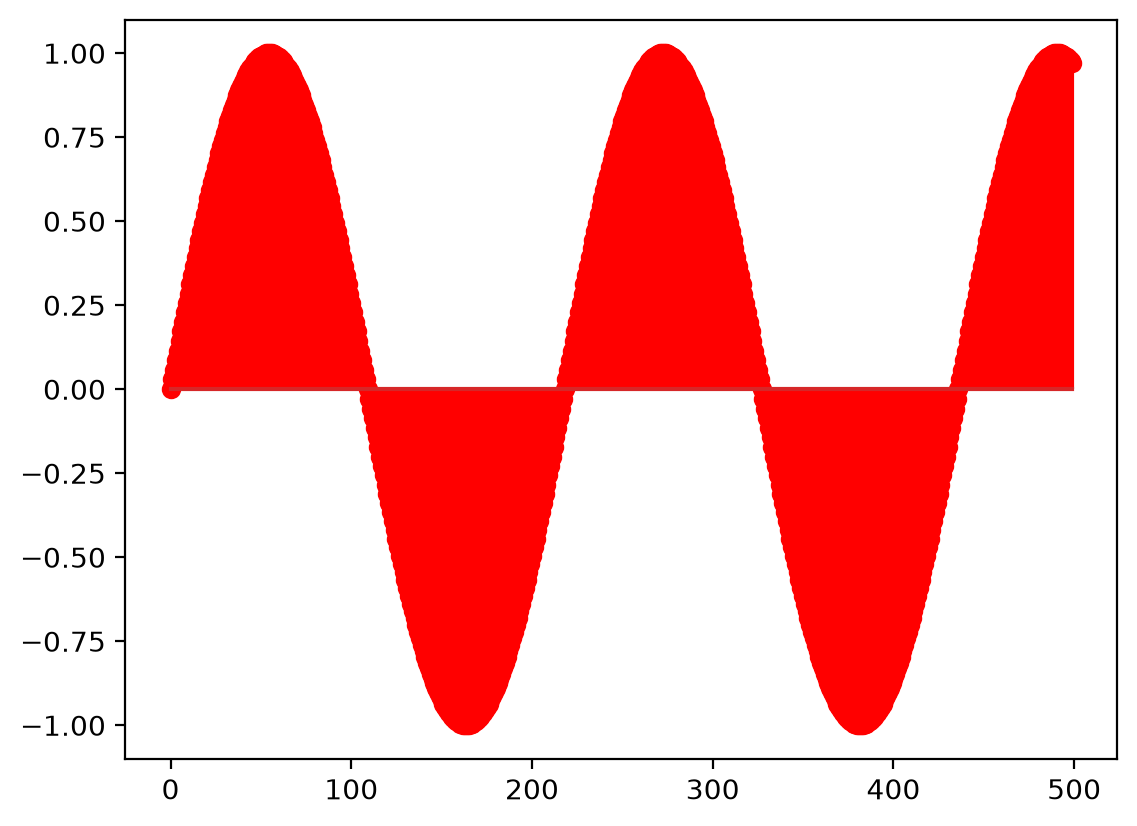

In [34]:
'''
Vetor de tempo
'''
fs=48e3
N1 = int(dur*fs)
n = np.arange(N1)
t1 = n/fs

'''
Plot
'''
SIGNALplot(x1[:500], n[:500])

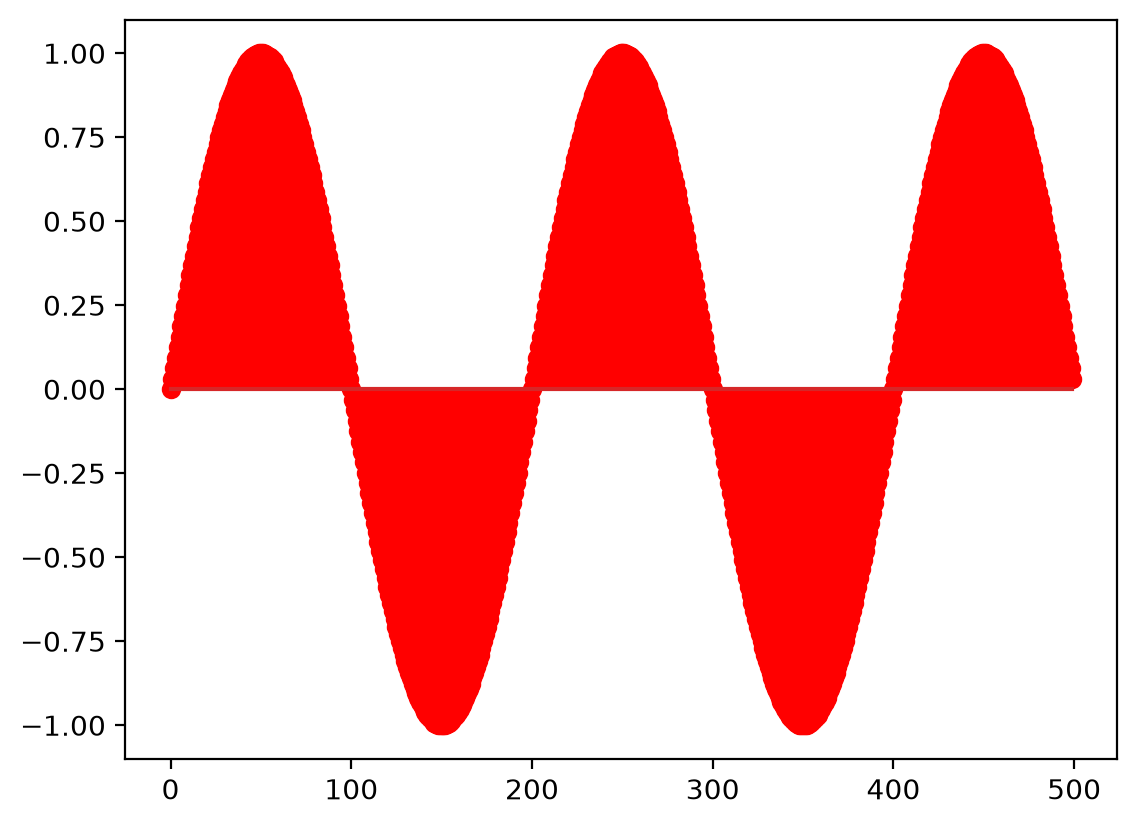

In [35]:
'''
Vetor de tempo
'''
t2 = n/fs2

'''
Plot
'''
SIGNALplot(x2[:500], t2[:500])

<img src="./figures/sine_01.png" alt="" width="600"/>

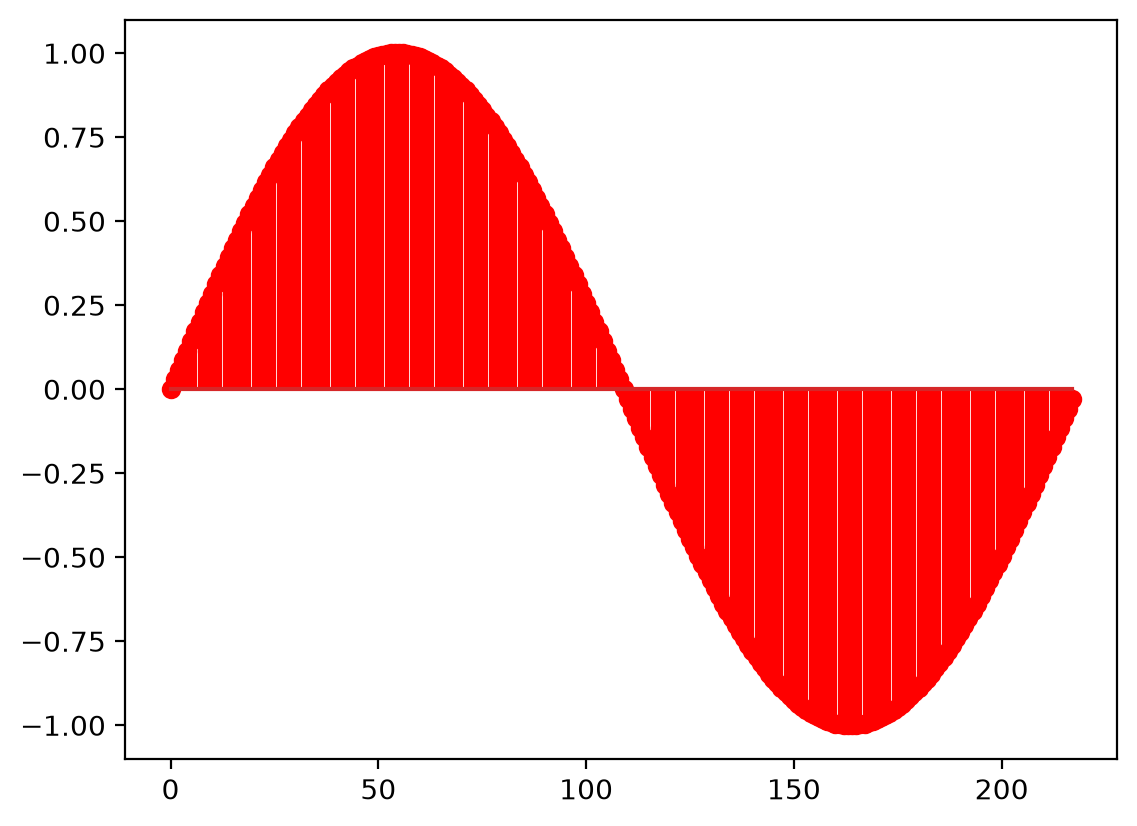

In [36]:
'''
Recorte
'''
r = P1

'''
Plot
'''
SIGNALplot(x1[:r], t1[:r])

<img src="./figures/sine_02.png" alt="" width="600"/>

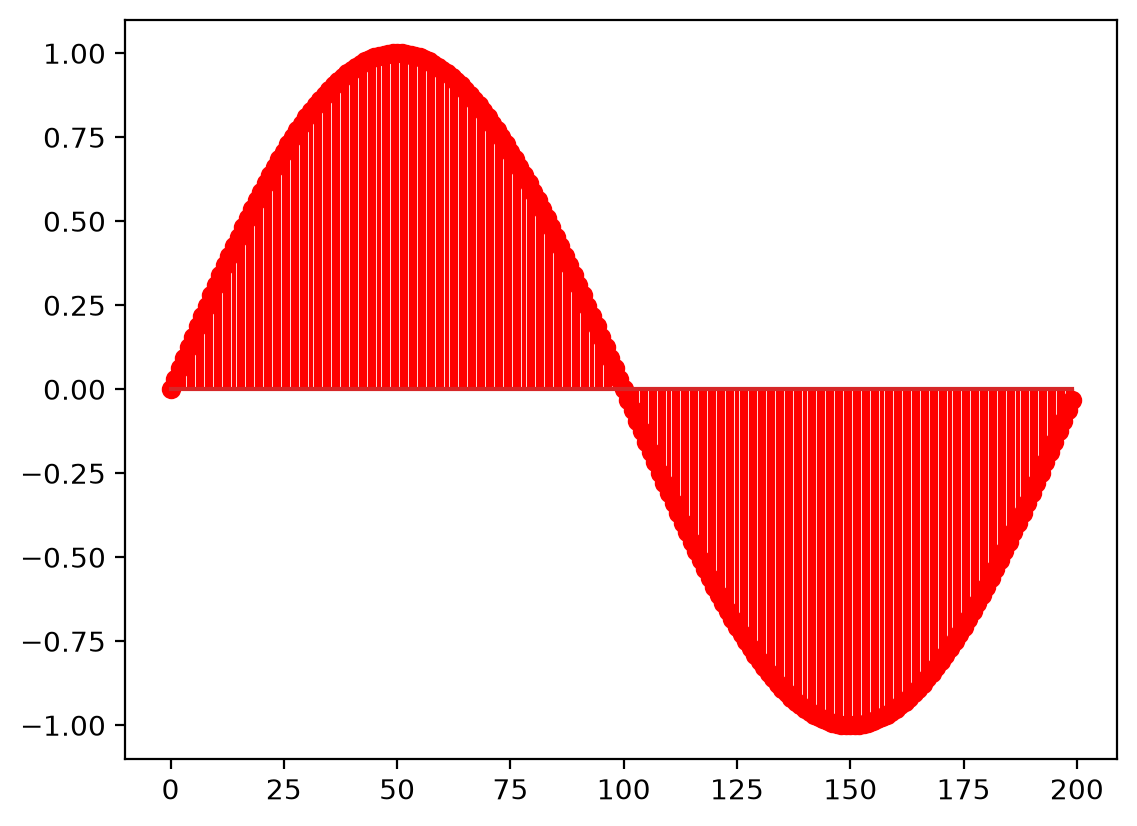

In [37]:
'''
Recorte
'''
r = P2

'''
Plot
'''
SIGNALplot(x2[:r], t2[:r])

Faça um novo recorte para plotar ***apenas*** 2.5 períodos de cada sinal.

***Dica:*** Verifique o resultado mostrando o **eixo horizontal** no "***domínio das amostras***".

<img src="./figures/sine_03.png" alt="" width="600"/>

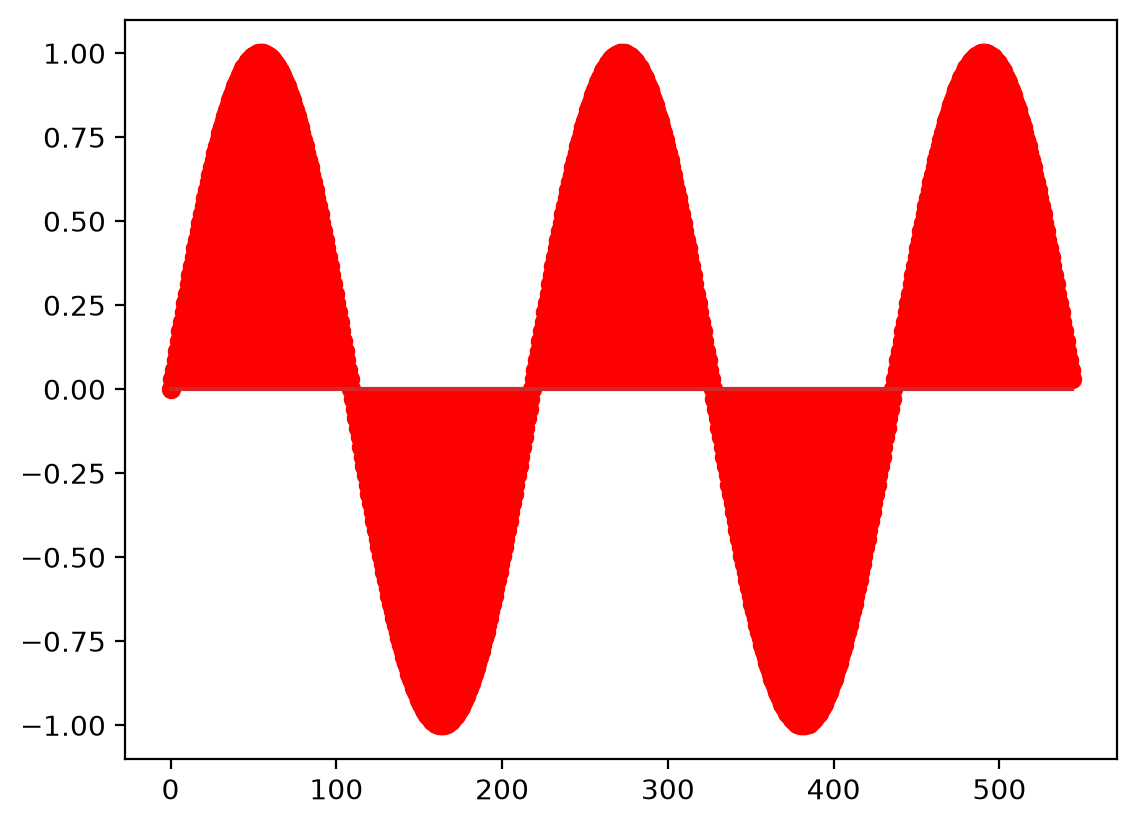

In [40]:
'''
Recorte
'''
n1 = np.arange(N1)
r = int(2.5* P1)

SIGNALplot(x1[:r], n1[:r])

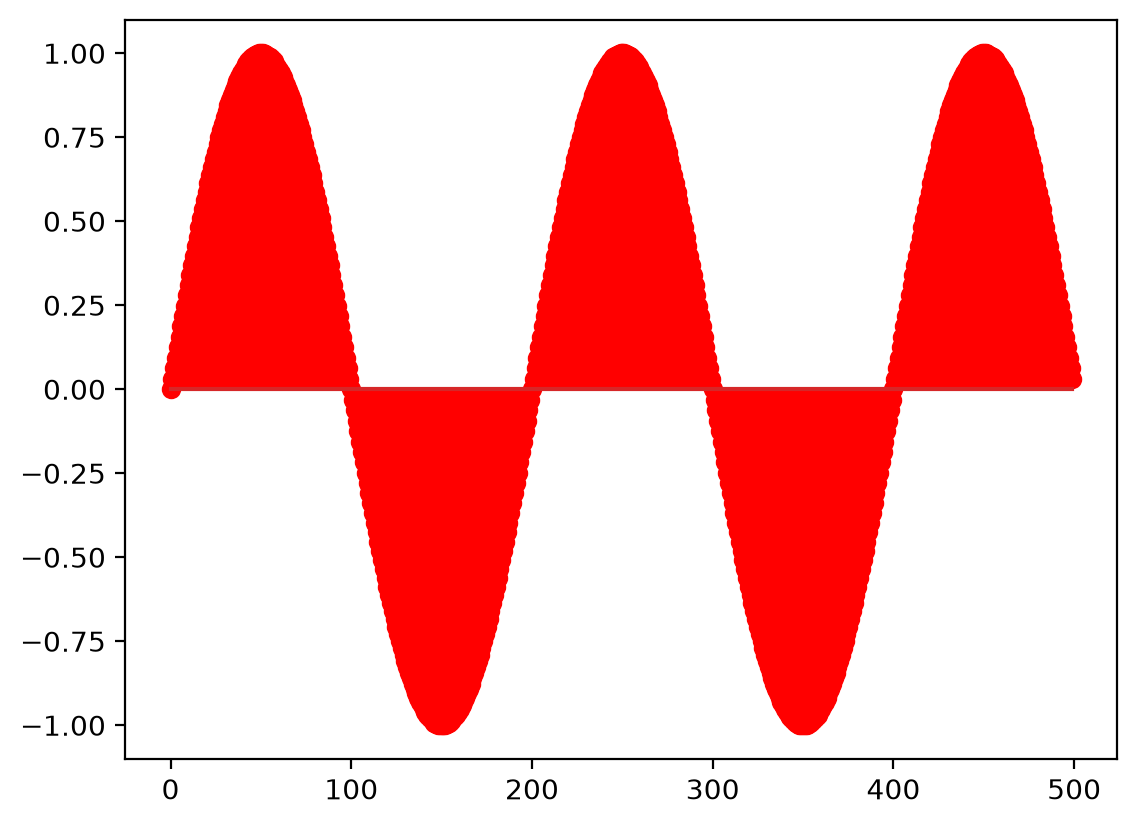

In [43]:
'''
Recorte
'''
r = int(2.5 *P2)
n2 = np.arange(N2)

SIGNALplot(x2[:r], n2[:r])

## Desafio

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALtone`, que permita criar um ***tom*** controlado por ***frequencia*** e ***duração***.

In [44]:
def SIGNALtone(f=440.0, dur=1.0):
    '''
    Tone with predefined frequency and duration

    f  : Signal frequency (Hz)
    dur: Duration (s)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''
    
    fs = 44100 # Sampling freq. (CD standard)
    N = int(dur*fs)
    P = np.round(fs/f).astype(int)

    x= SIGNALgenerate(N=N,signal='osc',params={'P': P})

    return x, fs

Teste a função para um sinal de 330 Hz com 3 segundos de duração.

In [45]:
f = 330.0 # signal freq (Hz)
dur = 3.0 # duration (s)

In [46]:
x, fs = SIGNALtone(f, dur)

In [47]:
play(x, fs)

## Revelando a "*velocidade*" dos sinais

Como comprovar que estamos gerando as frequências corretas?

***Dica:*** Estude a função `np.fft.fft` que permite evidenciar as "*velocidades*" de sinais. \
Use `SIGNALplot` para plotar a **magnitude** da FFT no domínio das amostras.

<img src="./figures/spec_01.png" alt="" width="600"/>

In [48]:
help(np.fft.fft)

Help on _ArrayFunctionDispatcher in module numpy.fft:

fft(a, n=None, axis=-1, norm=None, out=None)
    Compute the one-dimensional discrete Fourier Transform.
    
    This function computes the one-dimensional *n*-point discrete Fourier
    Transform (DFT) with the efficient Fast Fourier Transform (FFT)
    algorithm [CT]_.
    
    Parameters
    ----------
    a : array_like
        Input array, can be complex.
    n : int, optional
        Length of the transformed axis of the output.
        If `n` is smaller than the length of the input, the input is cropped.
        If it is larger, the input is padded with zeros.  If `n` is not given,
        the length of the input along the axis specified by `axis` is used.
    axis : int, optional
        Axis over which to compute the FFT.  If not given, the last axis is
        used.
    norm : {"backward", "ortho", "forward"}, optional
        Normalization mode (see `numpy.fft`). Default is "backward".
        Indicates which direction 

In [57]:
fft = np.fft.fft(x1, axis=-1)


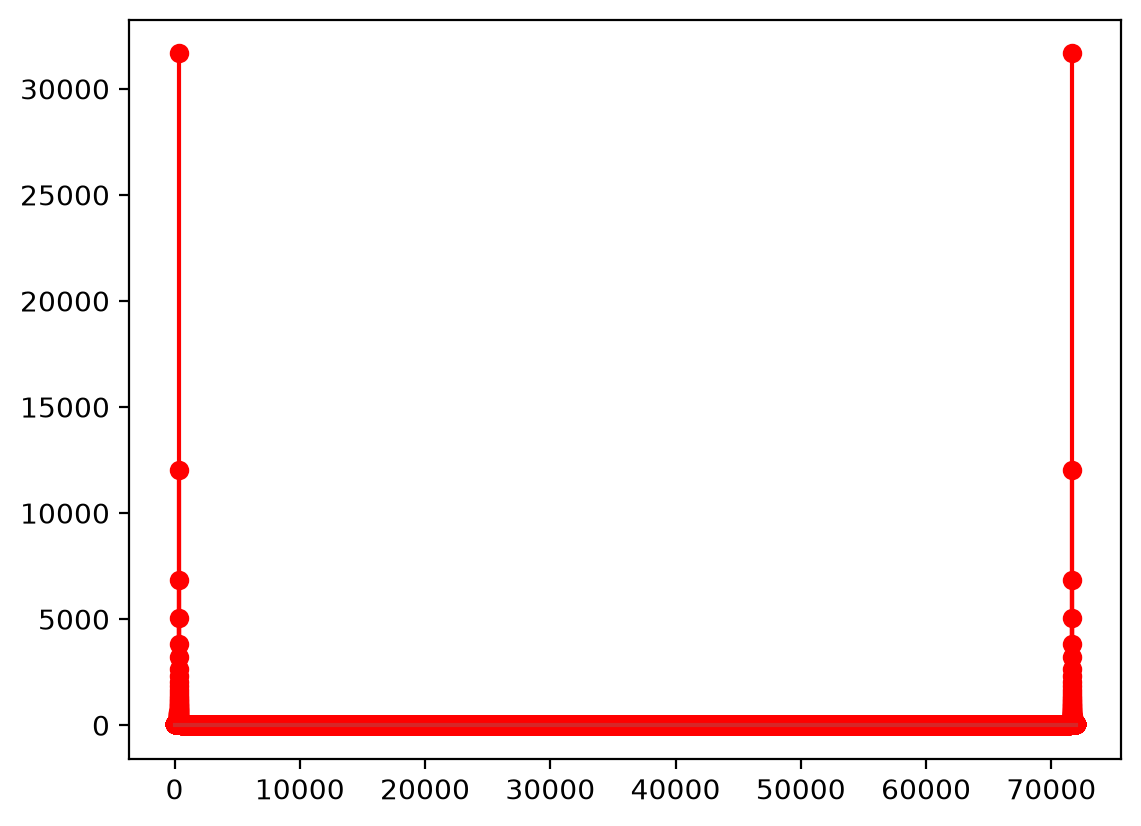

In [105]:
Xmag = np.abs(fft)
n = n1

SIGNALplot(Xmag, n)

Aproveitando a ***simetria***, faça um recorte, apropriado, de apenas a metade das amostras.

<img src="./figures/spec_02.png" alt="" width="600"/>

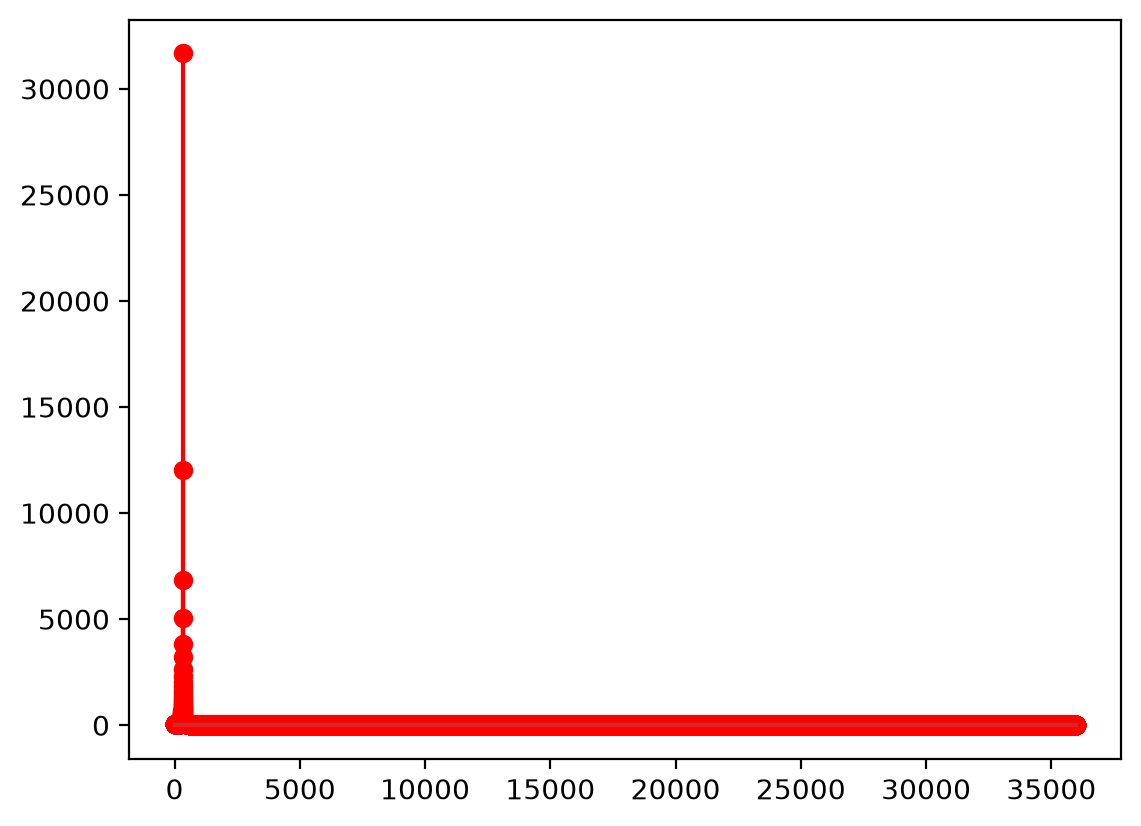

In [106]:
'''
Recorte no dominio das amostras
'''
r = int(len(n1)/2)

SIGNALplot(Xmag[:r], n[:r])

## Plotando as frequências

Agora vamos renomear o eixo horizontal para apresentar o sinal no "***domínio da frequência***":

$$
\Large
f = \frac{n}{N} f_{s}
$$

<img src="./figures/spec_03.png" alt="" width="600"/>

In [62]:
fHz = (n1/N1)*fs

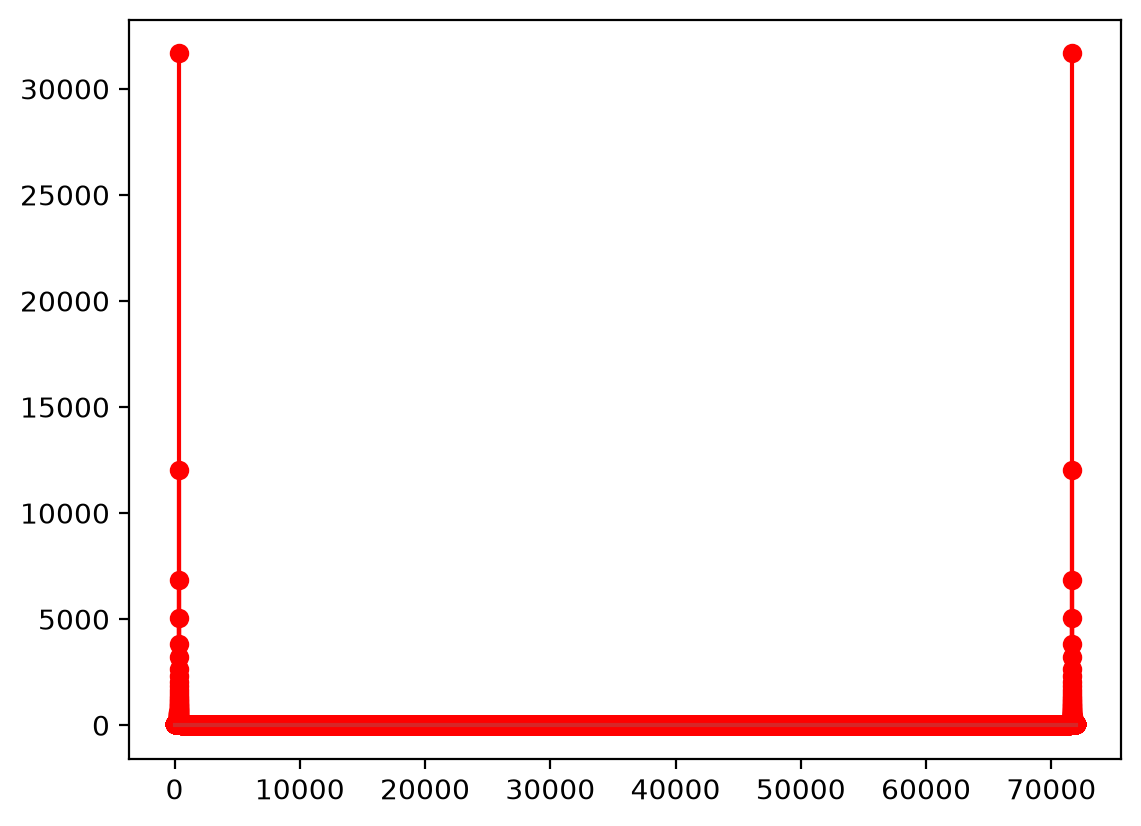

In [107]:
SIGNALplot(Xmag, fHz)

Aproveite o recorte anterior **no domínio das amostras** e aplique-o no sinal.

<img src="./figures/spec_04.png" alt="" width="600"/>

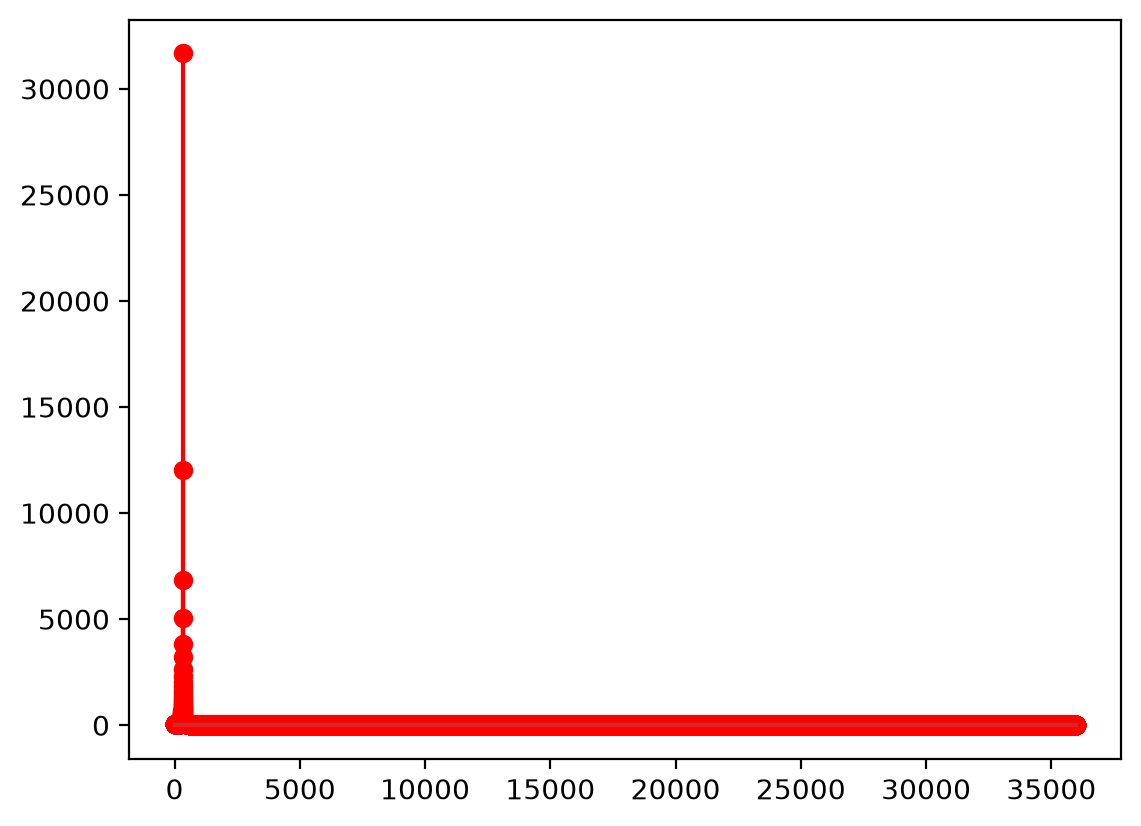

In [108]:
'''
Recorte no dominio das amostras
'''
r = int(len(n1)/2)

SIGNALplot(Xmag[:r], fHz[:r])

Agora, aplique um recorte similar **no domínio das frequências**.

<img src="./figures/spec_05.png" alt="" width="600"/>

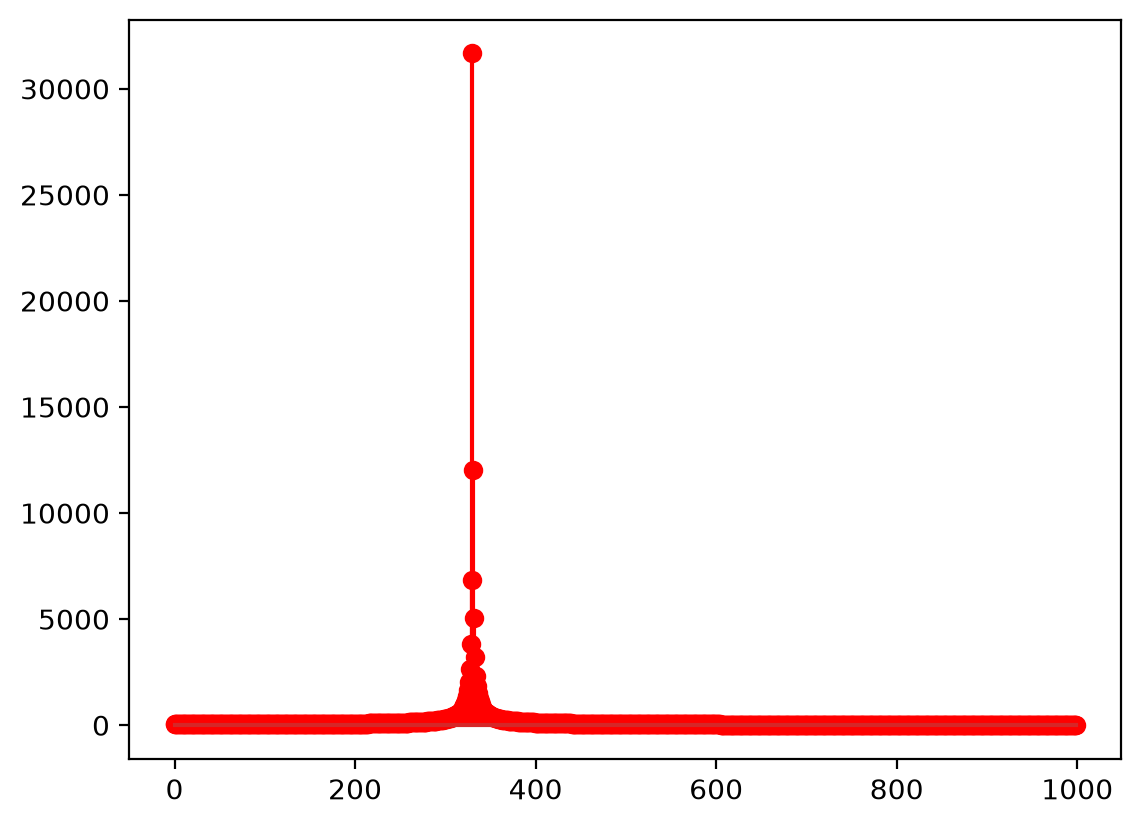

In [109]:
'''
Recorte no dominio das frequencias
'''
SIGNALplot(Xmag[:1000], fHz[:1000])

Plote a ***forma de onda*** e o ***espectro*** para um único sinal com frequencias de 200, 400, 600 e 800 Hz e 1 segundo de duração.

<img src="./figures/sine_04.png" alt="" width="600"/>

<img src="./figures/spec_06.png" alt="" width="600"/>

In [173]:
a, fs = create_sine_signal(f=200.0, dur=1.0)
b, fs = create_sine_signal(f=400.0, dur=1.0)
c, fs = create_sine_signal(f=600.0, dur=1.0)
d, fs = create_sine_signal(f=800.0, dur=1.0)

In [172]:
N = 4*len(n1)
x = np.arange(N)
tx = x/fs
fs_x = fs

In [174]:
x = a+b+c+d

In [175]:
play(x,fs)

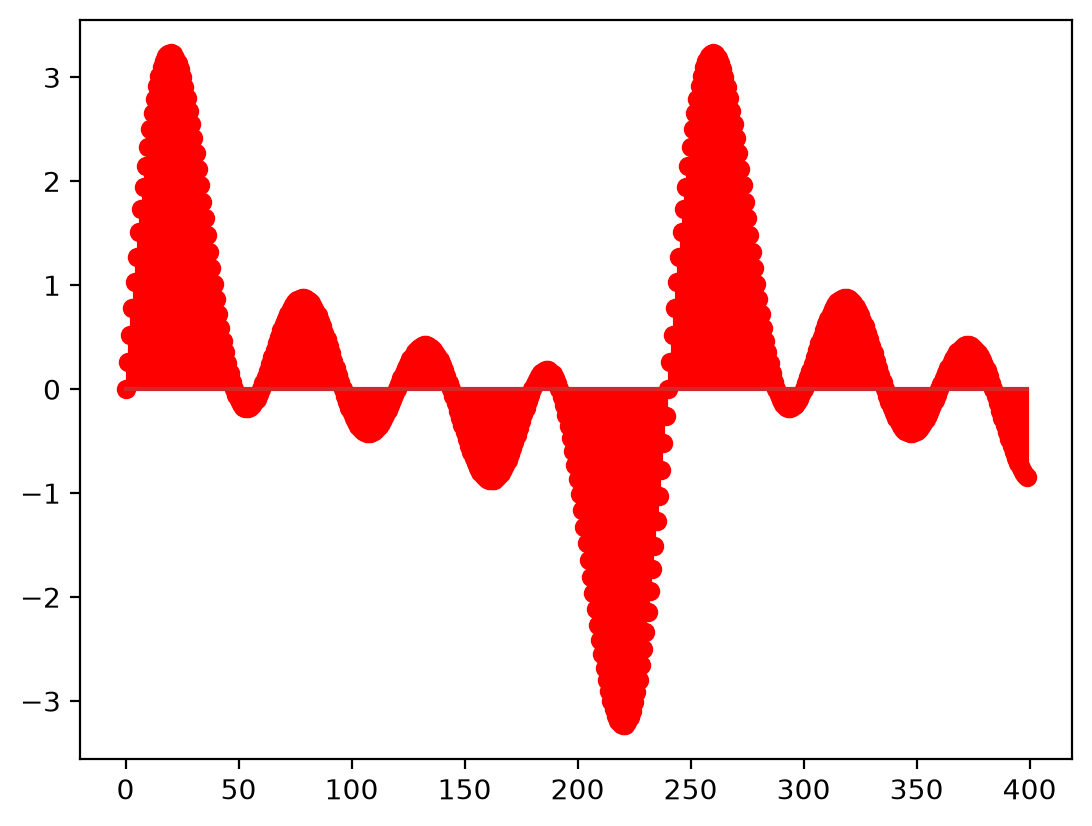

In [176]:
SIGNALplot(x[:400], tx[:400])

In [179]:
fHz_x= (np.arange(N)/4*len(n1))*fs_x

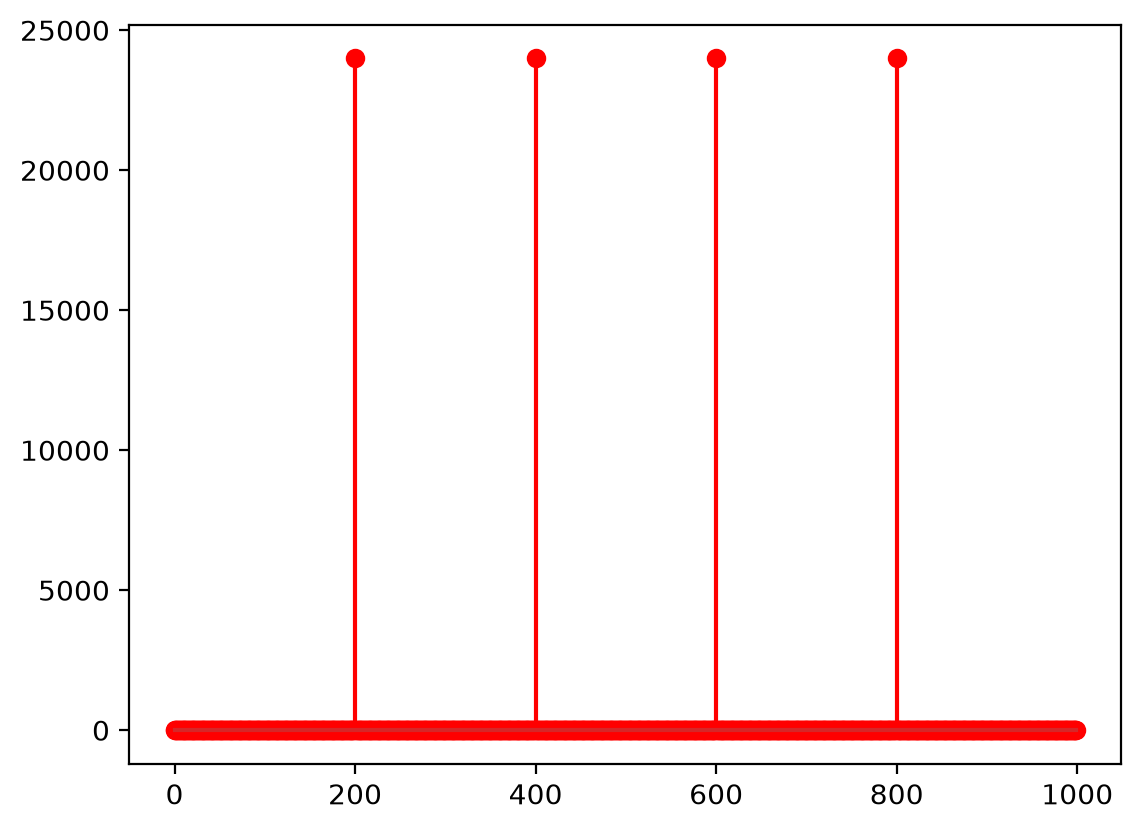

In [180]:
fft2 = np.fft.fft(x, axis=-1)
Xmag2 = np.abs(fft2)
SIGNALplot(Xmag2[:1000], fHz_x[:1000])

Oba! Agora sim conseguimos gerar e comprovar as frequencias, ou "*velocidades*", presentes nos sinais!

## Bonus track

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALwaveform`, que admita ***tons*** com [***formas de onda*** (*waveforms*)](https://en.wikipedia.org/wiki/Waveform) aleatórias.

***Dica:*** Comece criando um sinal aleatório de tamanho igual a um período. Depois é apenas replicar o sinal até o tamanho final usando `np.concatenate`.

In [156]:
def SIGNALwaveform(f=440.0, dur=1.0):
    '''
    Tone with a random waveform as input

    f  : Signal frequency
    dur: Duration (seconds)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''

    fs =  44100  # Sampling freq. (CD standard)
    N = int(dur*fs)
    P = np.round(fs/f).astype(int)

    waveform = SIGNALgenerate(N=P, signal = 'random')
    repetitions = int(np.ceil(N/P))
    x = np.tile(waveform, repetitions)
    x = x[:N]

    return x, fs

Teste a função para um sinal de 110 Hz e 1 segundo de duração.

In [157]:
f = 110.0
dur = 1.0

y, fs = SIGNALwaveform(f, dur)

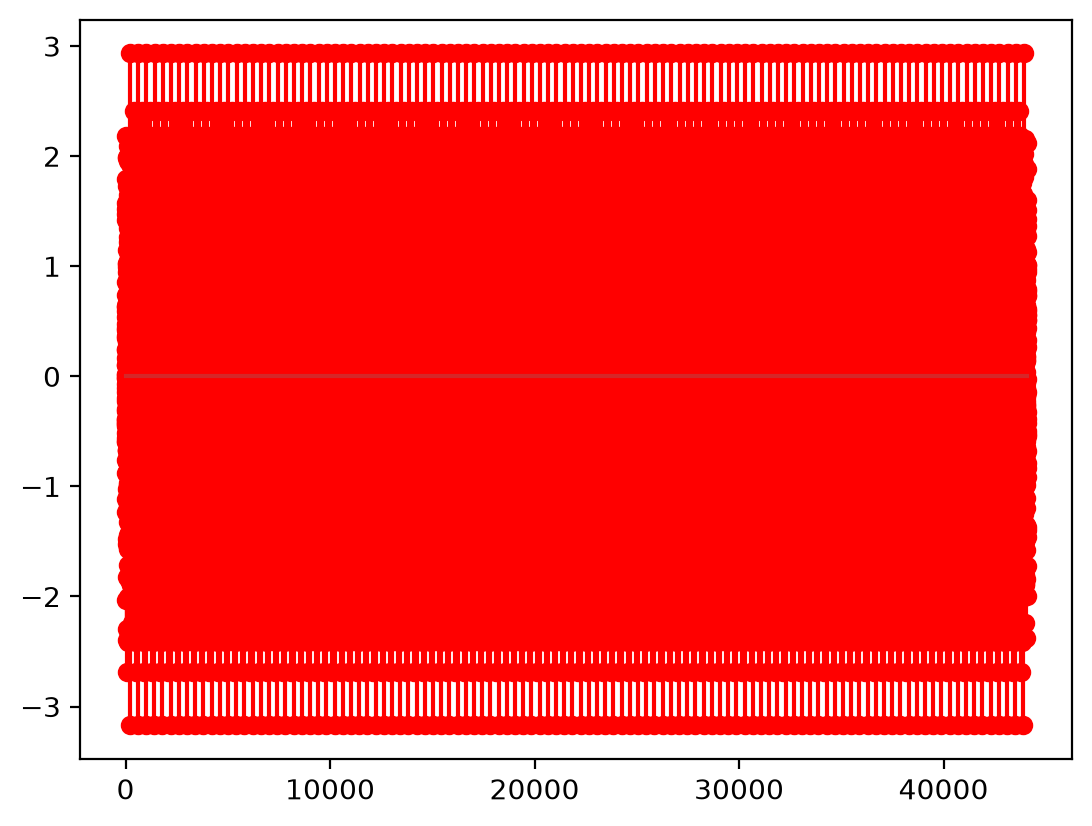

In [165]:
SIGNALplot(y, n1)

In [159]:
play(y, fs)

Verifique a frequencia do sinal gerado. \
O que achou de diferente nele?

<img src="./figures/spec_07.png" alt="" width="600"/>

In [160]:
ffty = np.fft.fft(y, axis=-1)
Ymag = np.abs(ffty)

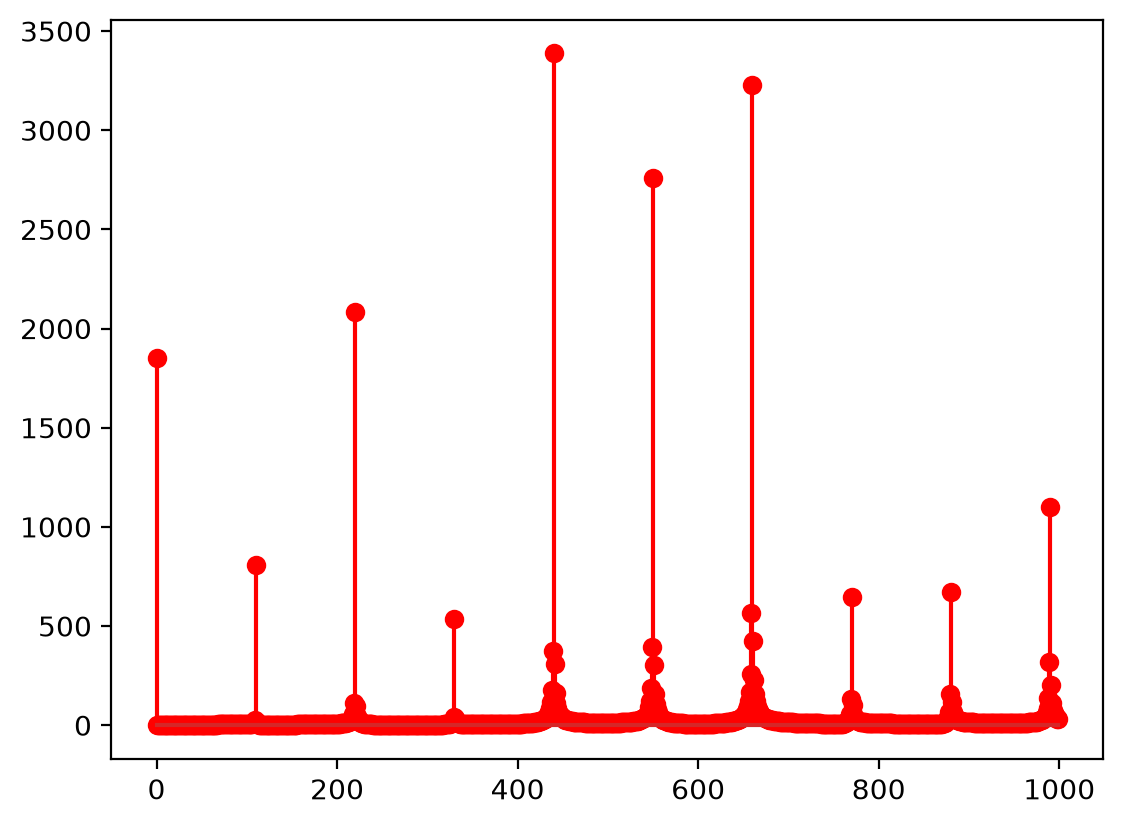

In [184]:
SIGNALplot(Ymag[:1000], na[:1000])

Plote apenas 5 períodos do sinal.

<img src="./figures/signal_01.png" alt="" width="600"/>

In [163]:

fs =  44100  # Sampling freq. (CD standard)
N = int(dur*fs)
P = np.round(fs/f).astype(int)

P5 = 5*P

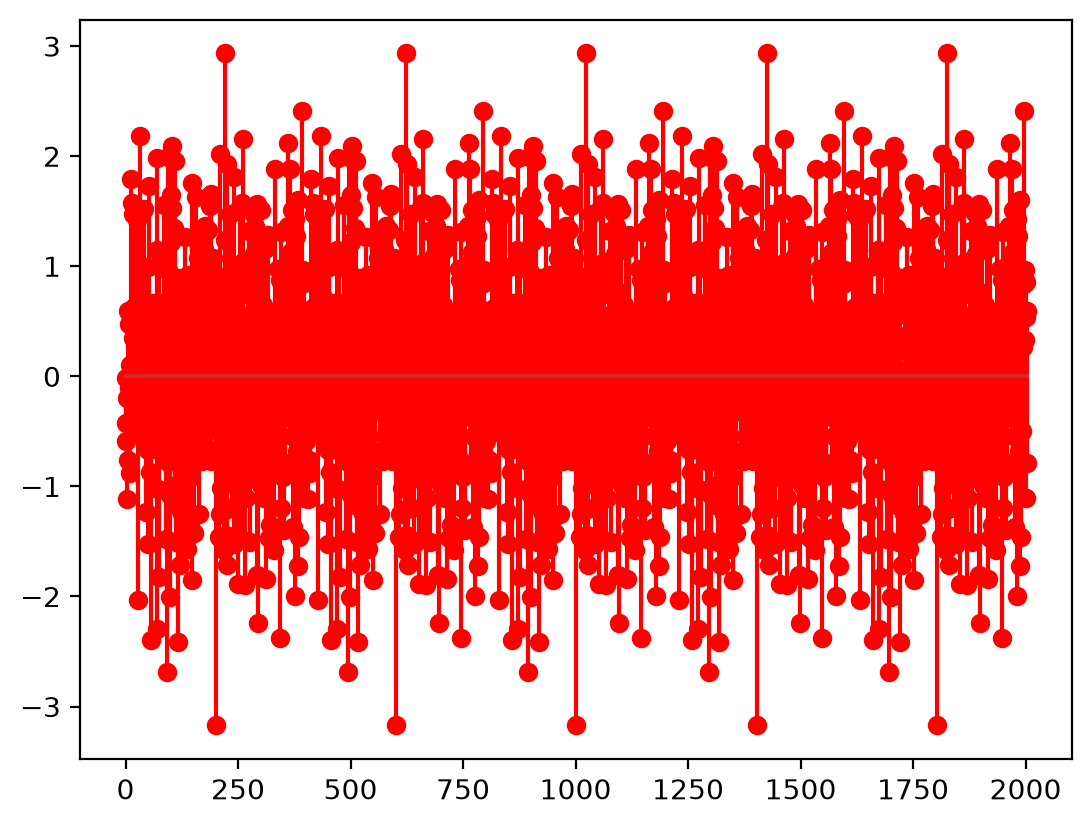

In [167]:
SIGNALplot(y[:P5], na[:P5])

Pronto! Agora estamos preparados para analisar sinais no ***domínio da frequência!***